In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import classification_report

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder


In [74]:
df = pd.read_csv('../dataset/motorcycles_clean.csv')

In [81]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 361 entries, 0 to 360
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Company              361 non-null    str  
 1   Country of Origin    361 non-null    str  
 2   Model                361 non-null    str  
 3   Number of cc         360 non-null    str  
 4   Horsepower           361 non-null    str  
 5   Torque               360 non-null    str  
 6   Transmission Type    361 non-null    str  
 7   Drivetrain           361 non-null    str  
 8   Number of Seating    361 non-null    str  
 9   Year                 361 non-null    str  
 10  Looks                361 non-null    str  
 11  Body Type            361 non-null    str  
 12  Engine Type          361 non-null    str  
 13  Number of Cylinders  360 non-null    str  
 14  Price (SEK)          361 non-null    str  
 15  Usage Type           359 non-null    str  
dtypes: str(16)
memory usage: 78.5 KB


In [62]:
df.dropna(inplace=True)
df.info()

<class 'pandas.DataFrame'>
Index: 0 entries
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Company              0 non-null      str    
 1   Country of Origin    0 non-null      str    
 2   Model                0 non-null      float64
 3   Number of cc         0 non-null      float64
 4   Horsepower           0 non-null      float64
 5   Torque               0 non-null      str    
 6   Transmission Type    0 non-null      str    
 7   Drivetrain           0 non-null      int64  
 8   Number of Seating    0 non-null      int64  
 9   Year                 0 non-null      str    
 10  Looks                0 non-null      str    
 11  Body Type            0 non-null      str    
 12  Engine Type          0 non-null      float64
 13  Number of Cylinders  0 non-null      float64
 14  Price (SEK)          0 non-null      float64
dtypes: float64(6), int64(2), str(7)
memory usage: 0.0 bytes


| Usage category                      | Body Types                                                 | Typisk användning                                   |
| ----------------------------------- | ---------------------------------------------------------- | --------------------------------------------------- |
| **Off-road / Gravel / Forest**      | Enduro                                                     | Grus, skog, terräng och off-road                    |
| **Touring / Long-distance**         | Adventure + vissa Cruiser                                  | Längre resor, komfort, stabilitet                   |
| **Race / Track**                    | Sport                                                      | Bankörning, hög prestanda och sportig körning       |
| **Lightweight / Beginner / Street** | Naked/Street + Scooter + Standard + Cafe Racer + Scrambler | Stad, vardagskörning, nybörjare och lättare körning |
| **Cruise / Comfort**                | Cruiser                                                    | Tyngre motorcyklar, cruising, komfort och stil      |


In [76]:
body_type_mapping = {
    "Enduro": "Off-road",
    
    "Adventure": "Touring",
    
    "Sport": "Race",
    
    "Naked/Street": "Street",
    "Scooter": "Street",
    "Standard": "Street",
    "Cafe Racer": "Street",
    "Scrambler": "Street",
    
    "Cruiser": "Cruise"
}

In [77]:
df["Usage Type"] = df["Body Type"].map(body_type_mapping)
df["Usage Type"].value_counts()

Usage Type
Street      186
Cruise       63
Off-road     39
Race         36
Touring      35
Name: count, dtype: int64

In [ ]:
# This one removes every csv entry
# df.to_csv("../dataset/motorcycles_clean.csv", index=False)
# df.columns

Index(['Company', 'Country of Origin', 'Model', 'Number of cc', 'Horsepower',
       'Torque', 'Transmission Type', 'Drivetrain', 'Number of Seating',
       'Year', 'Looks', 'Body Type', 'Engine Type', 'Number of Cylinders',
       'Price (SEK)', 'Usage Type'],
      dtype='str')

In [85]:
df.dropna(inplace=True)
df.info()

<class 'pandas.DataFrame'>
Index: 357 entries, 1 to 360
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Company              357 non-null    str  
 1   Country of Origin    357 non-null    str  
 2   Model                357 non-null    str  
 3   Number of cc         357 non-null    str  
 4   Horsepower           357 non-null    str  
 5   Torque               357 non-null    str  
 6   Transmission Type    357 non-null    str  
 7   Drivetrain           357 non-null    str  
 8   Number of Seating    357 non-null    str  
 9   Year                 357 non-null    str  
 10  Looks                357 non-null    str  
 11  Body Type            357 non-null    str  
 12  Engine Type          357 non-null    str  
 13  Number of Cylinders  357 non-null    str  
 14  Price (SEK)          357 non-null    str  
 15  Usage Type           357 non-null    str  
dtypes: str(16)
memory usage: 80.7 KB


## Modell 1

In [86]:
numeric_features = [
    "Number of cc",
    "Horsepower",
    "Number of Cylinders",
    "Number of Seating",
]

X = df[numeric_features]
y = df["Usage Type"]

In [87]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.25, random_state=36, stratify=y_train_full)

#stratify gör att street, cruise, off-road, race och toruing blir ungefär lika i train, val och test. De är bra att göra för vi har en klassobalans där street innehåller betydligt fler 

In [88]:
# våra numeriska varibaler har väldigt olika skalor använder vi standardscaler för att skala vår data

#fit_trasnform endast på träningsdatan för att undvika data läckage

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)



In [89]:
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [90]:
log_reg_pred = log_reg.predict(X_val_scaled)

In [91]:
print(classification_report(y_val, log_reg_pred))

              precision    recall  f1-score   support

      Cruise       0.29      0.15      0.20        13
    Off-road       0.00      0.00      0.00         8
        Race       0.75      0.43      0.55         7
      Street       0.57      0.92      0.70        37
     Touring       0.00      0.00      0.00         7

    accuracy                           0.54        72
   macro avg       0.32      0.30      0.29        72
weighted avg       0.42      0.54      0.45        72



/home/david/repos/mc_match/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/david/repos/mc_match/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/david/repos/mc_match/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

The baseline model performs best on Street motorcycles but struggles with Off-road and Touring. The low macro F1-score of 0.30 shows that the model does not classify all usage types equally well. This suggests that numerical features alone are not sufficient.


## Model 2 - adding categorical features
In this model, we add Looks and country of origin to investigate whether categorical features imporve the classification performance

In [92]:
categorical_features = [
    "Looks",
    "Country of Origin"
]

X_2 = df[numeric_features + categorical_features]
y_2 = df["Usage Type"]

In [93]:
X_train_full_2, X_test_2, y_train_full_2, y_test_2 = train_test_split(X_2, y_2, test_size=0.2, random_state=42, stratify=y_2)
X_train_2, X_val_2, y_train_2, y_val_2 = train_test_split(X_train_full_2, y_train_full_2, test_size=0.25, random_state=36, stratify=y_train_full_2)

In [94]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

#scale our numeric features
#OHE convert the categorical columns to numeric columns
#handle_unknown="ignore" makes sure the model doesn't crasch if a category shows up in val/test that wasn't in traindata

In [95]:
X_train_2_scaled = preprocessor.fit_transform(X_train_2)
X_val_2_scaled = preprocessor.transform(X_val_2)
X_test_2_scaled = preprocessor.transform(X_test_2)

In [96]:
log_reg_2 = LogisticRegression()

log_reg_2.fit(X_train_2_scaled, y_train_2)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [97]:
log_reg_2_pred = log_reg_2.predict(X_val_2_scaled)
print(classification_report(y_val_2, log_reg_2_pred))

              precision    recall  f1-score   support

      Cruise       0.57      0.31      0.40        13
    Off-road       0.50      0.25      0.33         8
        Race       0.50      0.29      0.36         7
      Street       0.62      0.84      0.71        37
     Touring       0.71      0.71      0.71         7

    accuracy                           0.61        72
   macro avg       0.58      0.48      0.50        72
weighted avg       0.60      0.61      0.58        72



Adding categorical features improved the model, especially the macro F1-score from 0.30 to 0.44. The model also became better at identifying Off-road and Touring motorcycles, although some classes are still difficult to classify.


## Model 3
Adding more categorical features

In [98]:
categorical_features_2 = [
    "Looks"
]

In [99]:
X_3 = df[numeric_features + categorical_features_2]
y_3 = df["Usage Type"]

In [100]:
X_train_full_3, X_test_3, y_train_full_3, y_test_3 = train_test_split(
    X_3, y_3,
    test_size=0.2,
    random_state=42,
    stratify=y_3
)

X_train_3, X_val_3, y_train_3, y_val_3 = train_test_split(
    X_train_full_3, y_train_full_3,
    test_size=0.25,
    random_state=36,
    stratify=y_train_full_3
)

In [101]:
preprocessor_3 = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_2)
    ]
)

In [102]:
X_train_3_scaled = preprocessor_3.fit_transform(X_train_3)
X_val_3_scaled = preprocessor_3.transform(X_val_3)
X_test_3_scaled = preprocessor_3.transform(X_test_3)

In [103]:
log_reg_3 = LogisticRegression()

log_reg_3.fit(X_train_3_scaled, y_train_3)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [104]:
log_reg_pred_3 = log_reg_3.predict(X_val_3_scaled)

print(classification_report(y_val_3, log_reg_pred_3))

              precision    recall  f1-score   support

      Cruise       0.57      0.31      0.40        13
    Off-road       0.50      0.25      0.33         8
        Race       0.60      0.43      0.50         7
      Street       0.61      0.81      0.70        37
     Touring       0.71      0.71      0.71         7

    accuracy                           0.61        72
   macro avg       0.60      0.50      0.53        72
weighted avg       0.60      0.61      0.59        72



Adding the remaining categorical features slightly improved the macro F1-score to 0.47. The model is better at identifying Off-road and Cruise motorcycles, although the overall performance is still limited.


In [105]:
feature_names = preprocessor_3.get_feature_names_out()
coefficients = log_reg_3.coef_
print(feature_names)


['num__Number of cc' 'num__Horsepower' 'num__Number of Cylinders'
 'num__Number of Seating' 'cat__Looks_Adventure' 'cat__Looks_Classic'
 'cat__Looks_Cruiser' 'cat__Looks_Modern' 'cat__Looks_Off-road'
 'cat__Looks_Practical' 'cat__Looks_Retro' 'cat__Looks_Sport'
 'cat__Looks_Urban']


In [106]:
print(coefficients.shape)

(5, 13)


In [107]:
feature_importance = np.mean(np.abs(coefficients), axis=0)

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

importance_df.head(10)

,Feature,Importance
4,cat__Looks_Adventure,1.126288
11,cat__Looks_Sport,0.739579
10,cat__Looks_Retro,0.708952
5,cat__Looks_Classic,0.607698
0,num__Number of cc,0.526884
3,num__Number of Seating,0.429761
6,cat__Looks_Cruiser,0.422757
8,cat__Looks_Off-road,0.419715
2,num__Number of Cylinders,0.391225
1,num__Horsepower,0.286450


In [108]:
# Gruppera OneHot-features tillbaka till sina ursprungliga variabler

grouped_importance = {}

for feature, importance in zip(feature_names, feature_importance):

    if feature.startswith("num__"):
        original_feature = feature.replace("num__", "")

    elif feature.startswith("cat__"):
        feature_without_prefix = feature.replace("cat__", "")

        original_feature = next(
            col for col in categorical_features_2
            if feature_without_prefix.startswith(col + "_")
        )

    if original_feature not in grouped_importance:
        grouped_importance[original_feature] = []

    grouped_importance[original_feature].append(importance)


# Beräkna genomsnittlig importance för varje ursprunglig variabel
grouped_importance_df = pd.DataFrame({
    "Feature": grouped_importance.keys(),
    "Importance": [
        np.mean(values)
        for values in grouped_importance.values()
    ]
})

grouped_importance_df = grouped_importance_df.sort_values(
    "Importance",
    ascending=False
)

grouped_importance_df

,Feature,Importance
0,Number of cc,0.526884
4,Looks,0.521676
3,Number of Seating,0.429761
2,Number of Cylinders,0.391225
1,Horsepower,0.286450


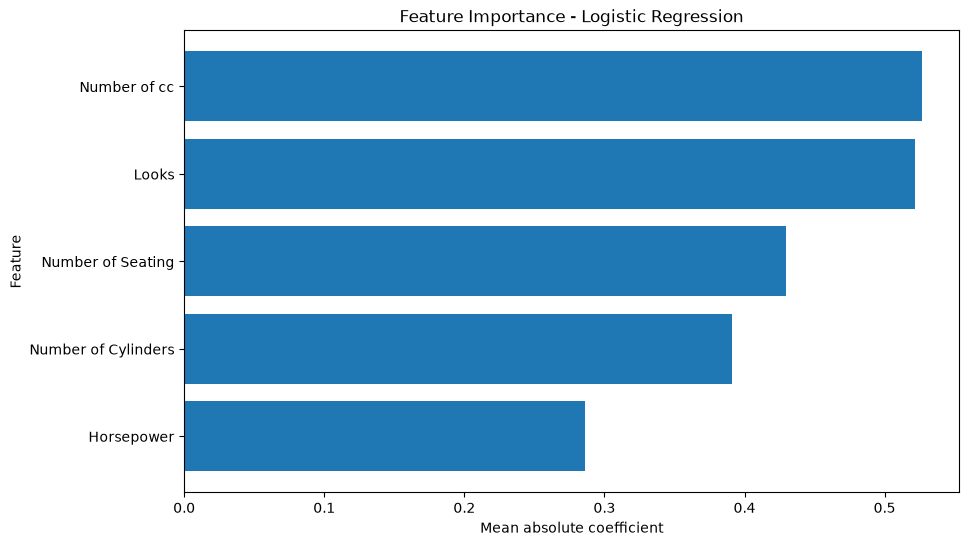

In [109]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    grouped_importance_df["Feature"],
    grouped_importance_df["Importance"]
)

plt.xlabel("Mean absolute coefficient")
plt.ylabel("Feature")
plt.title("Feature Importance - Logistic Regression")
plt.gca().invert_yaxis()

plt.show()

In [110]:
from sklearn.ensemble import RandomForestClassifier

In [111]:
rf = RandomForestClassifier(
    n_estimators=200, 
    random_state=42
)

rf.fit(X_train_3_scaled, y_train_3)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [112]:
rf_pred = rf.predict(X_val_3_scaled)

In [113]:
print(classification_report(y_val_3, rf_pred))

              precision    recall  f1-score   support

      Cruise       0.62      0.62      0.62        13
    Off-road       1.00      0.62      0.77         8
        Race       0.20      0.14      0.17         7
      Street       0.67      0.76      0.71        37
     Touring       0.43      0.43      0.43         7

    accuracy                           0.62        72
   macro avg       0.58      0.51      0.54        72
weighted avg       0.63      0.62      0.62        72



In [114]:
rf_importance = rf.feature_importances_

rf_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_importance
})

rf_importance_df = rf_importance_df.sort_values(
    "Importance",
    ascending=False
)

rf_importance_df.head(15)

,Feature,Importance
1,num__Horsepower,0.328288
0,num__Number of cc,0.287873
4,cat__Looks_Adventure,0.077952
3,num__Number of Seating,0.065235
2,num__Number of Cylinders,0.062832
5,cat__Looks_Classic,0.050762
11,cat__Looks_Sport,0.037764
7,cat__Looks_Modern,0.037582
10,cat__Looks_Retro,0.023999
8,cat__Looks_Off-road,0.015813


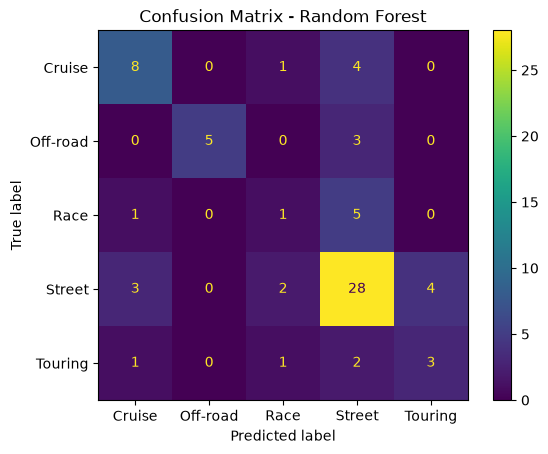

In [115]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_4 = confusion_matrix(y_val_3, rf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_4,
    display_labels=rf.classes_
)

disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [116]:
rf_balanced = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_balanced.fit(X_train_3_scaled, y_train_3)

rf_pred_balanced = rf_balanced.predict(X_val_3_scaled)

print(classification_report(y_val_3, rf_pred_balanced))

              precision    recall  f1-score   support

      Cruise       0.62      0.77      0.69        13
    Off-road       0.83      0.62      0.71         8
        Race       0.18      0.29      0.22         7
      Street       0.74      0.54      0.62        37
     Touring       0.50      0.86      0.63         7

    accuracy                           0.60        72
   macro avg       0.58      0.62      0.58        72
weighted avg       0.65      0.60      0.61        72



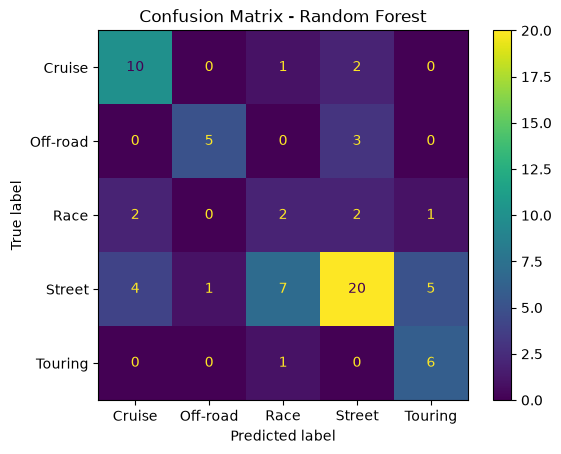

In [117]:
cm_5 = confusion_matrix(y_val_3, rf_pred_balanced)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_5,
    display_labels=rf_balanced.classes_
)

disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [118]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

In [119]:
preprocessor_rf = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_2)
    ]
)

In [120]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor_rf),
    ("classifier", RandomForestClassifier(random_state=42))
])

In [121]:
param_grid_rf = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 5, 10, 15],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__class_weight": [None, "balanced"]
}

we focus on f1_macro as scroing because our classes are unbalanced. F1 is the score that tells us most about if our model is good or not  

In [122]:
gs_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid_rf,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1
)

In [123]:
gs_rf.fit(X_train_3, y_train_3)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__class_weight': [None, 'balanced'], 'classifier__max_depth': [None, 5, ...], 'classifier__min_samples_leaf': [1, 2, ...], 'classifier__min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score

In [124]:
print("Best parameters:")
print(gs_rf.best_params_)

print("\nBest macro F1:")
print(gs_rf.best_score_)

Best parameters:
{'classifier__class_weight': 'balanced', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}

Best macro F1:
0.5378497610101037


In [125]:
rf_best = gs_rf.best_estimator_

rf_best_pred = rf_best.predict(X_val_3)

print(classification_report(y_val_3, rf_best_pred))

              precision    recall  f1-score   support

      Cruise       0.47      0.69      0.56        13
    Off-road       0.64      0.88      0.74         8
        Race       0.20      0.29      0.24         7
      Street       0.81      0.46      0.59        37
     Touring       0.45      0.71      0.56         7

    accuracy                           0.56        72
   macro avg       0.51      0.61      0.54        72
weighted avg       0.64      0.56      0.56        72



We first compared Logistic Regression and Random Forest for the classification task. Random Forest achieved better performance and was therefore selected for further optimization.

Since the dataset contains imbalanced classes, we used class_weight="balanced to give more weight to the less frequent classes. We then used GridSearchCV to optimize the Random Forest hyperparameters.

The best parameters were 200 estimators, a maximum tree depth of 5, min_samples_leaf=1, min_samples_split=2, and class_weight="balanced.

The optimized model achieved a macro F1-score of 0.59 on the test set, compared to 0.57 for the original Random Forest model. Accuracy also increased slightly from 0.64 to 0.65.

Based on these results, the optimized Random Forest was selected as our final classification model. Although the improvement was relatively small, the optimized model performed slightly better overall and achieved a better balance between the different classes.


In [126]:
final_model = Pipeline([
    ("preprocessor", preprocessor_rf),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=5,
        min_samples_leaf=1,
        min_samples_split=2,
        class_weight="balanced",
        random_state=42
    ))
])

In [127]:
final_model.fit(X_train_full_3, y_train_full_3)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](5,)","['Cruise','Off-road','Race','Street','Touring']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['Number of cc','Horsepower','Number of Cylinders','Number of Seating', 'Looks']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'d

In [128]:
final_pred = final_model.predict(X_test_3)

In [129]:
print(classification_report(y_test_3, final_pred))

              precision    recall  f1-score   support

      Cruise       0.60      0.75      0.67        12
    Off-road       0.41      0.88      0.56         8
        Race       0.38      0.71      0.50         7
      Street       0.85      0.45      0.59        38
     Touring       0.57      0.57      0.57         7

    accuracy                           0.58        72
   macro avg       0.56      0.67      0.58        72
weighted avg       0.69      0.58      0.59        72



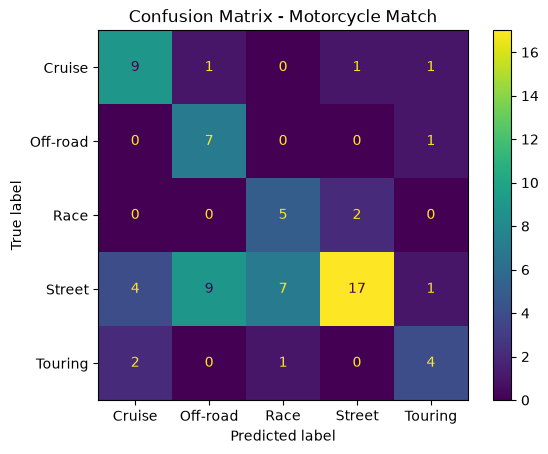

In [130]:
cm_final = confusion_matrix(y_test_3, final_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_final,
    display_labels=final_model.classes_
)

disp.plot()
plt.title("Confusion Matrix - Motorcycle Match")
plt.show()

### **Final Model**
After comparing Logistic Regression and Random Forest, Random Forest was selected because it performed better for this classification task. Since the dataset contains imbalanced classes, class_weight="balanced" was used to give more weight to the minority classes. GridSearchCV was then used to optimize the model, resulting in a Random Forest with 200 trees, a maximum depth of 5, and balanced class weights.

The final model achieved an accuracy of 64% and a macro F1-score of 0.65 on the unseen test set. The confusion matrix shows that the model performs particularly well for Off-road, while most of the remaining errors occur between Street, Race, and Cruise. This is reasonable since these categories can share similar characteristics, especially in terms of engine size, horsepower and overall motorcycle design.

Overall, the Random Forest model was chosen as the final model because it provided the best balance between performance across the different motorcycle categories and interpretability. After evaluation, the model was retrained on the complete dataset and saved for use in the Motorcycle Match application.

### **Final confusion matrix**
The confusion matrix shows that Street is the main source of misclassifications, with several Street motorcycles being predicted as Race or Cruise. Race motorcycles are also sometimes classified as Street, suggesting that these categories share similar characteristics. Cruise is classified relatively well, although some Cruise motorcycles are also predicted as Street, showing that the boundaries between these categories can overlap.

In [131]:
import joblib

final_model.fit(X_3, y_3)

joblib.dump(final_model, "../streamlit/models/motorcycle_classifier_test.joblib")

['../streamlit/models/motorcycle_classifier_test.joblib']